In [1]:
import sys
import numpy as np

print("Python :", sys.version)
print("NumPy  :", np.__version__)

Python : 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
NumPy  : 2.1.3


In [2]:
!pip install -q transformers datasets accelerate evaluate
!pip install -q scikit-learn pandas matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.7 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
import sklearn
import transformers
import datasets
import evaluate

print("NumPy       :", np.__version__)
print("Pandas      :", pd.__version__)
print("Scikit-learn:", sklearn.__version__)
print("Transformers:", transformers.__version__)
print("Datasets    :", datasets.__version__)

NumPy       : 2.1.3
Pandas      : 2.2.3
Scikit-learn: 1.6.1
Transformers: 5.16.1
Datasets    : 4.8.5


In [4]:
from datasets import load_dataset

ds = load_dataset("BenGaia/avis-clients")
print(ds)                        # splits et tailles

README.md:   0%|          | 0.00/582 [00:00<?, ?B/s]

reviews_FR_allSectors.jsonl:   0%|          | 0.00/3.86M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'rating'],
        num_rows: 15000
    })
})


In [5]:
print(ds["train"][0])
print(ds["train"].column_names)  # vrais noms de colonnes
print(ds["train"].features)

{'text': 'Belle surprise pour ce service (voyage/agence). hôtel de qualité ; vol au top. Quelques petits détails à améliorer, mais le rapport qualité-prix reste bon. Le contact a été fluide et professionnel. Les informations fournies étaient précises et utiles. Je pourrais revenir.', 'rating': 8}
['text', 'rating']
{'text': Value('string'), 'rating': Value('int64')}


In [6]:
import pandas as pd
df = ds["train"].to_pandas()
df.head()

,text,rating
0,Belle surprise pour ce service (voyage/agence)...,8
1,Passez votre chemin. sécurité mal géré ; anima...,2
2,Bon service pour ce service (mode). retours au...,7
3,Décevant pour ce service (télécom). réseau pro...,3
4,Expérience compliquée pour ce service (culture...,4


In [7]:
TEXT_COL = "text"
RATING_COL = "rating"
print(df.columns.tolist())

['text', 'rating']


In [8]:
print("Shape:", df.shape)
print("\nTypes:\n", df.dtypes)
print("\nValeurs manquantes:\n", df.isnull().sum())
print("\nDoublons:", df.duplicated().sum())
print("\nDoublons sur le texte:", df.duplicated(subset=[TEXT_COL]).sum())

Shape: (15000, 2)

Types:
 text      object
rating     int64
dtype: object

Valeurs manquantes:
 text      0
rating    0
dtype: int64

Doublons: 13

Doublons sur le texte: 22


In [9]:
df["text_length"] = df[TEXT_COL].astype(str).apply(len)
df["word_count"]  = df[TEXT_COL].astype(str).apply(lambda t: len(t.split()))
print(df["word_count"].describe())

print("\n--- Avis les plus courts ---")
print(df.nsmallest(3, "text_length")[[TEXT_COL, "text_length"]])
print("\n--- Avis les plus longs ---")
print(df.nlargest(3, "text_length")[[TEXT_COL, "text_length"]])

count    15000.000000
mean        33.308133
std         12.573337
min          8.000000
25%         26.000000
50%         32.000000
75%         43.000000
max         73.000000
Name: word_count, dtype: float64

--- Avis les plus courts ---
                                                    text  text_length
14000  Très déçu. réseau décevant ; box mal géré. Plu...           55
7087   À éviter. délais décevant ; devis mal géré. Pl...           56
10951  À éviter. délais mal géré ; devis mal géré. Pl...           56

--- Avis les plus longs ---
                                                    text  text_length
453    Quelques points à revoir pour ce service (loca...          465
8363   Globalement satisfaisant pour ce service (loca...          460
14921  Bien mais perfectible pour ce service (éducati...          458


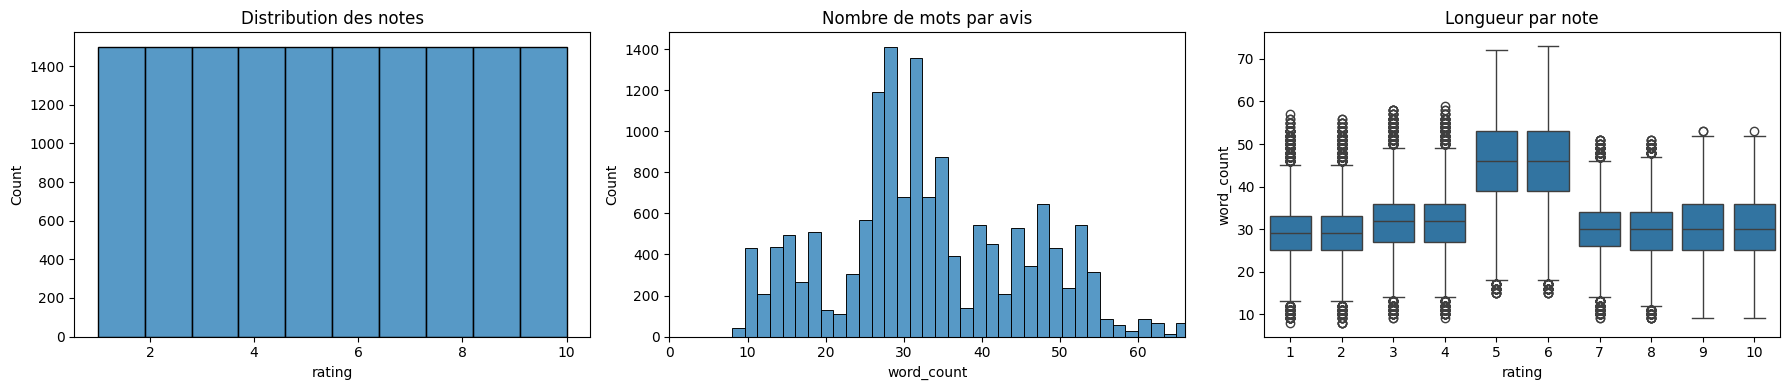

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(df[RATING_COL], bins=10, ax=axes[0]); axes[0].set_title("Distribution des notes")
sns.histplot(df["word_count"], bins=40, ax=axes[1]); axes[1].set_title("Nombre de mots par avis")
axes[1].set_xlim(0, df["word_count"].quantile(0.99))
sns.boxplot(x=df[RATING_COL], y=df["word_count"], ax=axes[2]); axes[2].set_title("Longueur par note")
plt.tight_layout(); plt.show()

In [11]:
def rating_to_label(rating):
    if rating <= 4:
        return 0   # Negative
    elif rating <= 6:
        return 1   # Neutral
    else:
        return 2   # Positive

df["label"] = df[RATING_COL].apply(rating_to_label)
label_names = {0: "Negative", 1: "Neutral", 2: "Positive"}
df["sentiment"] = df["label"].map(label_names)

print(df["sentiment"].value_counts())
print(df["sentiment"].value_counts(normalize=True).round(3))

sentiment
Positive    6000
Negative    6000
Neutral     3000
Name: count, dtype: int64
sentiment
Positive    0.4
Negative    0.4
Neutral     0.2
Name: proportion, dtype: float64


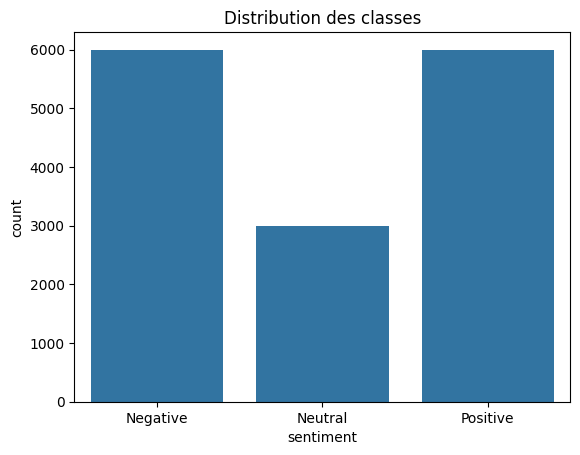

In [12]:
sns.countplot(x="sentiment", data=df, order=["Negative", "Neutral", "Positive"])
plt.title("Distribution des classes"); plt.show()

In [13]:
import re

def clean_text_for_transformer(text):
    text = str(text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)   # URLs
    text = re.sub(r"<.*?>", " ", text)                # HTML résiduel
    text = re.sub(r"\s+", " ", text).strip()          # espaces multiples
    return text

df["clean_text"] = df[TEXT_COL].apply(clean_text_for_transformer)

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

X, y = df["clean_text"], df["label"]
X_train_bl, X_test_bl, y_train_bl, y_test_bl = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train_bl)
X_test_tfidf  = tfidf.transform(X_test_bl)

baseline_model = LogisticRegression(max_iter=1000, class_weight="balanced")
baseline_model.fit(X_train_tfidf, y_train_bl)
y_pred_bl = baseline_model.predict(X_test_tfidf)

baseline_acc = accuracy_score(y_test_bl, y_pred_bl)
baseline_f1 = precision_recall_fscore_support(y_test_bl, y_pred_bl, average="macro")[2]
print("Accuracy:", round(baseline_acc, 4), "| F1-macro:", round(baseline_f1, 4))
print(classification_report(y_test_bl, y_pred_bl, target_names=["Negative","Neutral","Positive"]))

Accuracy: 1.0 | F1-macro: 1.0
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00      1200
     Neutral       1.00      1.00      1.00       600
    Positive       1.00      1.00      1.00      1200

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



In [15]:
from datasets import Dataset, DatasetDict

train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["label"])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df["label"])
print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))

cols = ["clean_text", "label"]
hf_ds = DatasetDict({
    "train": Dataset.from_pandas(train_df[cols].reset_index(drop=True)),
    "validation": Dataset.from_pandas(val_df[cols].reset_index(drop=True)),
    "test": Dataset.from_pandas(test_df[cols].reset_index(drop=True)),
})

Train: 12000 Val: 1500 Test: 1500


In [16]:
from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

example = tokenizer("The hotel was excellent")
print("Tokens:", tokenizer.convert_ids_to_tokens(example["input_ids"]))
print("IDs:", example["input_ids"])
print("Attention mask:", example["attention_mask"])

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokens: ['[CLS]', 'the', 'hotel', 'was', 'excellent', '[SEP]']
IDs: [101, 1996, 3309, 2001, 6581, 102]
Attention mask: [1, 1, 1, 1, 1, 1]


In [17]:
MAX_LENGTH = 128  # ajuste selon la distribution de word_count (étape 2)

def tokenize_fn(batch):
    return tokenizer(batch["clean_text"], padding="max_length", truncation=True, max_length=MAX_LENGTH)

tokenized_ds = hf_ds.map(tokenize_fn, batched=True)
tokenized_ds = tokenized_ds.remove_columns(["clean_text"])
tokenized_ds.set_format("torch")

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

Map:   0%|          | 0/1500 [00:00<?, ? examples/s]

In [18]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
import numpy as np
import evaluate

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    f1 = f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"]
    return {"accuracy": acc, "f1_macro": f1}

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [19]:
training_args = TrainingArguments(
    output_dir="./distilbert-sentiment",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    logging_steps=50,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_ds["train"],
    eval_dataset=tokenized_ds["validation"],
    compute_metrics=compute_metrics,
)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.000397,0.000254,1.000000,1.000000
2,0.000129,0.000083,1.000000,1.000000
3,0.000094,0.000059,1.000000,1.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2250, training_loss=0.013254303408165772, metrics={'train_runtime': 443.7731, 'train_samples_per_second': 81.123, 'train_steps_per_second': 5.07, 'total_flos': 1192227849216000.0, 'train_loss': 0.013254303408165772, 'epoch': 3.0})

In [20]:
test_results = trainer.predict(tokenized_ds["test"])
y_pred_db = np.argmax(test_results.predictions, axis=-1)
y_true_db = test_results.label_ids

db_acc = accuracy_score(y_true_db, y_pred_db)
db_f1 = precision_recall_fscore_support(y_true_db, y_pred_db, average="macro")[2]
print(classification_report(y_true_db, y_pred_db, target_names=["Negative","Neutral","Positive"]))

comparison = pd.DataFrame({
    "Model": ["TF-IDF + Logistic Regression", "DistilBERT (fine-tuned)"],
    "Accuracy": [round(baseline_acc, 4), round(db_acc, 4)],
    "F1_macro": [round(baseline_f1, 4), round(db_f1, 4)],
})
print(comparison)

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00       600
     Neutral       1.00      1.00      1.00       300
    Positive       1.00      1.00      1.00       600

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500

                          Model  Accuracy  F1_macro
0  TF-IDF + Logistic Regression       1.0       1.0
1       DistilBERT (fine-tuned)       1.0       1.0


In [22]:
import torch
import torch.nn.functional as F

def predict_sentiment(text, model=model, tokenizer=tokenizer, max_length=MAX_LENGTH):
    model.eval()
    device = next(model.parameters()).device
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=max_length).to(device)
    with torch.no_grad():
        logits = model(**inputs).logits
    probs = F.softmax(logits, dim=-1).squeeze().cpu().numpy()
    pred_id = int(probs.argmax())
    return {
        "sentiment": label_names[pred_id],
        "confidence": float(probs[pred_id]),
        "probabilities": {label_names[i]: float(probs[i]) for i in range(3)},
    }

print(predict_sentiment("The room was clean but the service was very slow."))

{'sentiment': 'Negative', 'confidence': 0.4391457140445709, 'probabilities': {'Negative': 0.4391457140445709, 'Neutral': 0.19071851670742035, 'Positive': 0.3701357841491699}}


In [23]:
import json, os

SAVE_DIR = "./saved_model"
os.makedirs(SAVE_DIR, exist_ok=True)
model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)
with open(os.path.join(SAVE_DIR, "label_mapping.json"), "w") as f:
    json.dump(label_names, f)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]